In [7]:
!pip install -q imbalanced-learn xgboost shap kaggle

In [8]:
from google.colab import files
print("Upload your kaggle.json (Kaggle > Settings > API > Create New Token)")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

Upload your kaggle.json (Kaggle > Settings > API > Create New Token)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 107MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


Shape: (284807, 31)

Class balance:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727 %


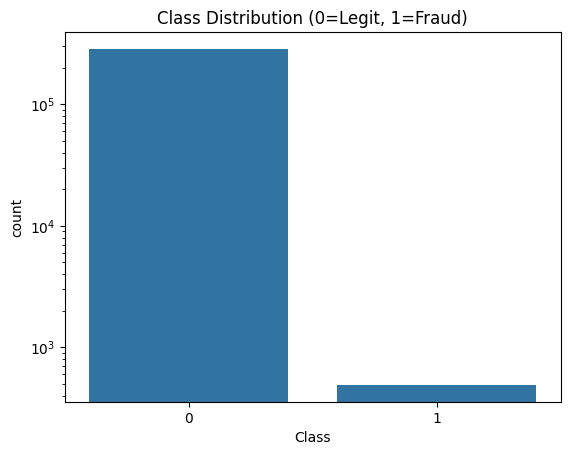

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("\nClass balance:\n", df['Class'].value_counts())
print("\nFraud %:", round(df['Class'].mean()*100, 4), "%")

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0=Legit, 1=Fraud)")
plt.yscale('log')  # log scale, else the fraud bar is invisible
plt.show()

Preprocess


In [10]:
from sklearn.preprocessing import StandardScaler

df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_scaled'] = StandardScaler().fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

Stratified split (this order matters — split BEFORE any resampling)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train fraud rate:", round(y_train.mean()*100, 4), "%")
print("Test fraud rate:", round(y_test.mean()*100, 4), "%")
print("Train fraud count:", y_train.sum(), "| Test fraud count:", y_test.sum())

Train fraud rate: 0.1729 %
Test fraud rate: 0.172 %
Train fraud count: 394 | Test fraud count: 98


Build 3 imbalance-handling variants

In [13]:
from imblearn.over_sampling import SMOTE

# Variant A: raw imbalanced data (baseline, for comparison only)
X_train_raw, y_train_raw = X_train, y_train

# Variant B: SMOTE-resampled
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Variant C: will use class_weight='balanced' directly on raw data (no resampling)
print("Raw train:", y_train_raw.value_counts().to_dict())
print("SMOTE train:", y_train_smote.value_counts().to_dict())

Raw train: {0: 227451, 1: 394}
SMOTE train: {0: 227451, 1: 227451}


Train models across all variants

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scale_pos = (y_train_raw == 0).sum() / (y_train_raw == 1).sum()

configs = {
    "LogReg + SMOTE": (LogisticRegression(max_iter=1000), X_train_smote, y_train_smote),
    "LogReg + class_weight": (LogisticRegression(max_iter=1000, class_weight='balanced'), X_train_raw, y_train_raw),
    "RandomForest + SMOTE": (RandomForestClassifier(n_estimators=100, random_state=42), X_train_smote, y_train_smote),
    "RandomForest + class_weight": (RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_train_raw, y_train_raw),
    "XGBoost + SMOTE": (XGBClassifier(eval_metric='logloss', random_state=42), X_train_smote, y_train_smote),
    "XGBoost + scale_pos_weight": (XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss', random_state=42), X_train_raw, y_train_raw),
}

trained = {}
for name, (model, Xtr, ytr) in configs.items():
    model.fit(Xtr, ytr)
    trained[name] = model
    print(f"✓ {name} trained")

✓ LogReg + SMOTE trained
✓ LogReg + class_weight trained
✓ RandomForest + SMOTE trained
✓ RandomForest + class_weight trained
✓ XGBoost + SMOTE trained
✓ XGBoost + scale_pos_weight trained


In [15]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, average_precision_score, f1_score)

results = []
for name, model in trained.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    recall = tp / (tp + fn) if (tp+fn) > 0 else 0
    f1 = f1_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    results.append({
        "Model": name, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": round(precision, 4), "Recall": round(recall, 4),
        "F1": round(f1, 4), "ROC-AUC": round(roc_auc, 4), "PR-AUC": round(pr_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
print(results_df.to_string(index=False))

                      Model  TP   FP  FN    TN  Precision  Recall     F1  ROC-AUC  PR-AUC
 XGBoost + scale_pos_weight  81   10  17 56854     0.8901  0.8265 0.8571   0.9692  0.8727
       RandomForest + SMOTE  79   18  19 56846     0.8144  0.8061 0.8103   0.9688  0.8675
            XGBoost + SMOTE  84   39  14 56825     0.6829  0.8571 0.7602   0.9745  0.8662
RandomForest + class_weight  74    3  24 56861     0.9610  0.7551 0.8457   0.9581  0.8653
             LogReg + SMOTE  90 1458   8 55406     0.0581  0.9184 0.1094   0.9698  0.7249
      LogReg + class_weight  90 1389   8 55475     0.0609  0.9184 0.1141   0.9722  0.7189


Business cost framing

In [16]:
avg_fraud_amount = df[df['Class']==1]['Amount_scaled'].mean()  # placeholder — see note below
# Better: recompute from original unscaled data before you dropped 'Amount' in Cell 4,
# or re-load a copy of df just to get this number:
df_raw = pd.read_csv("creditcard.csv")
avg_fraud_loss = df_raw[df_raw['Class']==1]['Amount'].mean()
investigation_cost = 5  # your assumption — state this explicitly in your writeup

cost_results = []
for name, model in trained.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * avg_fraud_loss) + (fp * investigation_cost)
    cost_results.append({"Model": name, "Est. Cost ($)": round(total_cost, 2)})

cost_df = pd.DataFrame(cost_results).sort_values("Est. Cost ($)")
print(f"Avg fraud transaction amount: ${avg_fraud_loss:.2f}")
print(cost_df.to_string(index=False))

Avg fraud transaction amount: $122.21
                      Model  Est. Cost ($)
            XGBoost + SMOTE        1905.96
 XGBoost + scale_pos_weight        2127.59
       RandomForest + SMOTE        2412.02
RandomForest + class_weight        2948.07
      LogReg + class_weight        7922.69
             LogReg + SMOTE        8267.69


Feature importance

Best model by PR-AUC: XGBoost + scale_pos_weight


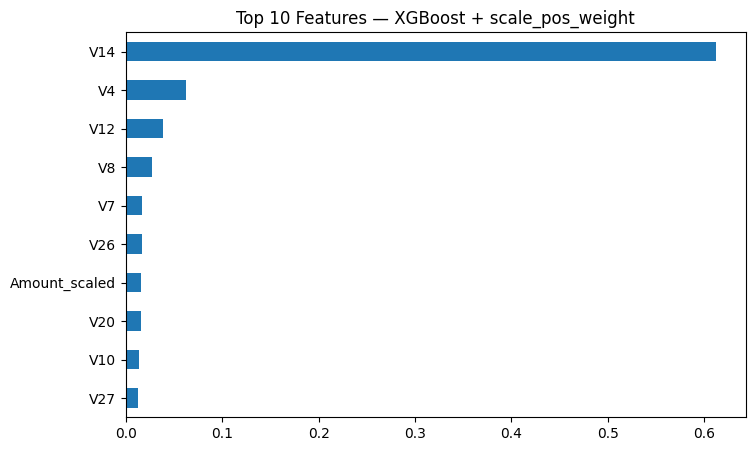

In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]
print("Best model by PR-AUC:", best_model_name)

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    importances.head(10).plot(kind='barh', figsize=(8,5))
    plt.title(f"Top 10 Features — {best_model_name}")
    plt.gca().invert_yaxis()
    plt.show()

Confusion matrix heatmap for best model

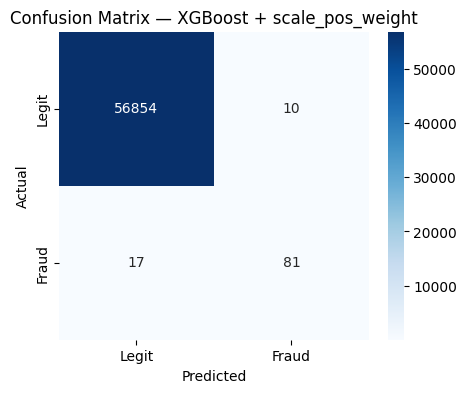

In [18]:
best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()